### Wing Weight Function — Forrester, Sóbester &amp; Keane (2008)

This notebook analyses the **wing weight function**, a standard
benchmark for surrogate modelling and sensitivity analysis in
aerospace engineering [1].  The function models the weight of a
light aircraft wing and is representative of a Cessna C172
Skyhawk [2].

**Model.**  Wing weight (lb) as a function of 10 geometric and
aerodynamic parameters:

$$
W = 0.036\,S_w^{0.758}\,W_{fw}^{0.0035}
      \left(\frac{A}{\cos^2\Lambda}\right)^{0.6}
      q^{0.006}\,\lambda^{0.04}
      \left(\frac{100\,t_c}{\cos\Lambda}\right)^{-0.3}
      (N_z\,W_{dg})^{0.49}
      + S_w\,W_p
$$

**Input variables** (10) — all independent Uniform distributions.
The inputs span a wide range of scales (orders of magnitude),
making this an interesting test of Shapley effect estimation
under mixed-variable-scale conditions.

---
[1] Forrester, A., Sóbester, A., &amp; Keane, A. (2008).
    *Engineering Design via Surrogate Modelling: A Practical Guide.*
    Wiley.
[2] Surjanovic, S. &amp; Bingham, D.  Virtual Library of Simulation
    Experiments: Test Functions and Datasets.
    https://www.sfu.ca/~ssurjano/wingweight.html
[3] Moon, H., Dean, A. M., &amp; Santner, T. J. (2012).
    Two-stage sensitivity-based group screening in computer
    experiments. *Technometrics*, 54(4), 376-387.

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from shapleyx.utilities.mc_shapley import (
    MultivariateNormal,
    GaussianCopulaUniform,
    shapley_effects,
)

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

Running on ShapleyX v0.5.1


---
### Input Distribution

Ten variables — all Uniform with the ranges from Forrester et al.
(2008).  Inputs are independent in the baseline analysis.

| # | Symbol | Description | Distribution | Range |
|---|---|---|---|---|
| 1 | $S_w$ | Wing area | $\mathcal{U}(150, 200)$ | ft² |
| 2 | $W_{fw}$ | Fuel weight in wing | $\mathcal{U}(220, 300)$ | lb |
| 3 | $A$ | Aspect ratio | $\mathcal{U}(6, 10)$ | — |
| 4 | $\Lambda$ | Quarter-chord sweep | $\mathcal{U}(-10, 10)$ | deg |
| 5 | $q$ | Dynamic pressure at cruise | $\mathcal{U}(16, 45)$ | lb/ft² |
| 6 | $\lambda$ | Taper ratio | $\mathcal{U}(0.5, 1)$ | — |
| 7 | $t_c$ | Airfoil thickness/chord ratio | $\mathcal{U}(0.08, 0.18)$ | — |
| 8 | $N_z$ | Ultimate load factor | $\mathcal{U}(2.5, 6)$ | — |
| 9 | $W_{dg}$ | Flight design gross weight | $\mathcal{U}(1700, 2500)$ | lb |
| 10 | $W_p$ | Paint weight | $\mathcal{U}(0.025, 0.08)$ | lb/ft² |

In [2]:
d = 10

# Variable labels and uniform ranges
labels = ['Sw', 'Wfw', 'A', 'Lambda', 'q', 'l', 'tc', 'Nz', 'Wdg', 'Wp']
descriptions = [
    'Wing area (ft²)',
    'Fuel weight in wing (lb)',
    'Aspect ratio',
    'Quarter-chord sweep (deg)',
    'Dynamic pressure at cruise (lb/ft²)',
    'Taper ratio',
    'Airfoil thickness/chord ratio',
    'Ultimate load factor',
    'Flight design gross weight (lb)',
    'Paint weight (lb/ft²)',
]

# Uniform bounds for each variable
lows = np.array([150, 220, 6, -10, 16, 0.5, 0.08, 2.5, 1700, 0.025])
highs = np.array([200, 300, 10, 10, 45, 1.0, 0.18, 6.0, 2500, 0.08])

print(f"{'Variable':>8s}  {'Range':>25s}  {'Description':s}")
print("-" * 75)
for i, (name, desc) in enumerate(zip(labels, descriptions)):
    print(f"{name:>8s}  [{lows[i]:6g}, {highs[i]:6g}]   {desc}")

Variable                      Range  Description
---------------------------------------------------------------------------
      Sw  [   150,    200]   Wing area (ft²)
     Wfw  [   220,    300]   Fuel weight in wing (lb)
       A  [     6,     10]   Aspect ratio
  Lambda  [   -10,     10]   Quarter-chord sweep (deg)
       q  [    16,     45]   Dynamic pressure at cruise (lb/ft²)
       l  [   0.5,      1]   Taper ratio
      tc  [  0.08,   0.18]   Airfoil thickness/chord ratio
      Nz  [   2.5,      6]   Ultimate load factor
     Wdg  [  1700,   2500]   Flight design gross weight (lb)
      Wp  [ 0.025,   0.08]   Paint weight (lb/ft²)


---
### Gaussian Copula Distribution

In the baseline (independent) analysis, we use the built-in
`GaussianCopulaUniform` class with an identity correlation matrix.
For the correlated extension (Section below), we introduce
physically-motivated correlations among geometric parameters.

**Correlated scenario** (optional extension):
- $\rho(S_w, A) = 0.6$ — larger wing area → higher aspect ratio
- $\rho(S_w, W_{dg}) = 0.7$ — larger wing → heavier aircraft
- $\rho(A, \lambda) = -0.4$ — higher aspect ratio → lower taper
- $\rho(\Lambda, q) = 0.3$ — more sweep → higher dynamic pressure

In [3]:
# --- Independent inputs (baseline) ---
corr_independent = np.eye(d)
joint_ind = GaussianCopulaUniform(lows, highs, corr_independent)

# --- Correlated inputs (extension) ---
corr_correlated = np.eye(d)
corr_correlated[0, 2] = corr_correlated[2, 0] = 0.6   # Sw ↔ A
corr_correlated[0, 8] = corr_correlated[8, 0] = 0.7   # Sw ↔ Wdg
corr_correlated[2, 5] = corr_correlated[5, 2] = -0.4  # A ↔ λ
corr_correlated[3, 4] = corr_correlated[4, 3] = 0.3   # Λ ↔ q

joint_corr = GaussianCopulaUniform(lows, highs, corr_correlated)

print("GaussianCopulaUniform distributions ready.")
print(f"Dimension: {d}")
print(f"Baseline: independent inputs")
print(f"Extension: 4 correlation pairs among geometric/aero params")

GaussianCopulaUniform distributions ready.
Dimension: 10
Baseline: independent inputs
Extension: 4 correlation pairs among geometric/aero params


---
### Wing Weight Model Function

In [4]:
def wing_weight(x):
    """Wing weight (lb) from Forrester et al. (2008).

    x = [Sw, Wfw, A, Lambda, q, l, tc, Nz, Wdg, Wp]
    """
    Sw, Wfw, A, Lambda, q, l, tc, Nz, Wdg, Wp = x

    # Convert sweep angle to radians for cos()
    cos_L = np.cos(np.deg2rad(Lambda))

    term1 = 0.036 * Sw**0.758 * Wfw**0.0035
    term2 = (A / cos_L**2)**0.6
    term3 = q**0.006 * l**0.04
    term4 = (100 * tc / cos_L)**(-0.3)
    term5 = (Nz * Wdg)**0.49
    term6 = Sw * Wp

    return term1 * term2 * term3 * term4 * term5 + term6


def wing_weight_batch(X):
    """Vectorised wing weight for batch evaluation."""
    Sw  = X[:, 0]
    Wfw = X[:, 1]
    A   = X[:, 2]
    Lambda = X[:, 3]
    q   = X[:, 4]
    l   = X[:, 5]
    tc  = X[:, 6]
    Nz  = X[:, 7]
    Wdg = X[:, 8]
    Wp  = X[:, 9]

    cos_L = np.cos(np.deg2rad(Lambda))

    term1 = 0.036 * Sw**0.758 * Wfw**0.0035
    term2 = (A / cos_L**2)**0.6
    term3 = q**0.006 * l**0.04
    term4 = (100 * tc / cos_L)**(-0.3)
    term5 = (Nz * Wdg)**0.49
    term6 = Sw * Wp

    return term1 * term2 * term3 * term4 * term5 + term6


# Quick sanity check at nominal values
x_nom = [175, 260, 8, 0, 30, 0.75, 0.13, 4.25, 2100, 0.0525]
W_nom = wing_weight(x_nom)
print(f"Nominal wing weight: {W_nom:.1f} lb")

Nominal wing weight: 267.6 lb


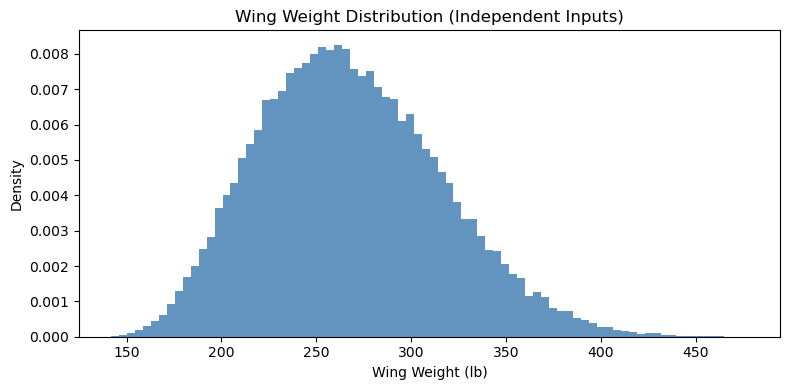

Wing weight range: [142, 478] lb
Mean: 268 lb, Std: 48 lb
CoV: 0.179


In [5]:
# Quick histogram of wing weight values
X_check = joint_ind.sample_joint(50000)
W_sample = wing_weight_batch(X_check)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(W_sample, bins=80, density=True, color='steelblue', alpha=0.85)
ax.set_xlabel('Wing Weight (lb)')
ax.set_ylabel('Density')
ax.set_title('Wing Weight Distribution (Independent Inputs)')
plt.tight_layout()
plt.show()

print(f"Wing weight range: [{W_sample.min():.0f}, {W_sample.max():.0f}] lb")
print(f"Mean: {W_sample.mean():.0f} lb, Std: {W_sample.std():.0f} lb")
print(f"CoV: {W_sample.std() / W_sample.mean():.3f}")

---
### Variance-Based Shapley Effects (Independent Inputs)

First, we compute **Shapley effects** on wing weight for the
independent-input case.  Since inputs are independent, Shapley
effects should fall between the first-order and total Sobol
indices.  We use the exhaustive method with $N = 10{,}000$
samples and $B = 200$ bootstrap replications.

For $d = 10$, exhaustive enumeration requires $2^{10} - 1 =
1{,}023$ subsets → $20{,}460{,}000$ evaluations.  This is
feasible for the analytical function but would be expensive
for a real model — motivating the RS-HDMR surrogate approach.

In [6]:
eff, sh, var, lower, upper = shapley_effects(
    wing_weight,
    joint_ind,
    N=10000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    predict_batch=wing_weight_batch,
    random_state=42,
    progress=True,
)

results = pd.DataFrame({
    'Variable': labels,
    'Effect': eff,
    'Lower': lower,
    'Upper': upper,
})
results

MC Shapley: 100%|██████████| 20450000/20450000 [00:20<00:00, 1003864.62evals/s]


,Variable,Effect,Lower,Upper
0,Sw,0.124984,1.217686e-01,0.128582
1,Wfw,0.001652,-2.564897e-03,0.005918
2,A,0.220398,2.162226e-01,0.225386
3,Lambda,0.004716,-1.463349e-04,0.009297
4,q,0.004073,-4.519701e-04,0.008516
5,l,0.003730,4.163689e-07,0.008512
6,tc,0.143120,1.401023e-01,0.146677
7,Nz,0.407349,3.974731e-01,0.417328
8,Wdg,0.086761,8.354658e-02,0.090464
9,Wp,0.003216,-1.764134e-03,0.007950


---
### RS-HDMR Surrogate Model

To demonstrate the surrogate-based workflow, we train an **RS-HDMR**
model on $2{,}048$ Sobol' samples covering the full input ranges.
The surrogate is then used for MC Shapley estimation and provides
Sobol first-order indices for validation against literature.

In [7]:
# Generate training data — Sobol' samples over full ranges
from scipy.stats.qmc import Sobol

N_train = 2048
sampler = Sobol(d=d, scramble=True, seed=123)
X_sobol = sampler.random(N_train)
# Scale to input ranges
X_train = lows + (highs - lows) * X_sobol
Y_train = wing_weight_batch(X_train)

# Build DataFrame for RS-HDMR
df_train = pd.DataFrame(X_train, columns=labels)
df_train['Y'] = Y_train

print(f"{len(df_train)} training samples")
print(f"Y range: [{Y_train.min():.1f}, {Y_train.max():.1f}] lb")
print(f"Mean: {Y_train.mean():.1f}, Std: {Y_train.std():.1f} lb")

2048 training samples
Y range: [155.2, 441.8] lb
Mean: 268.1, Std: 48.1 lb


Found a DataFrame

Transforming data to unit hypercube

Feature: Sw, Min Value: 150.0038, Max Value: 199.9855
Feature: Wfw, Min Value: 220.0070, Max Value: 299.9837
Feature: A, Min Value: 6.0005, Max Value: 9.9981
Feature: Lambda, Min Value: -9.9978, Max Value: 9.9923
Feature: q, Min Value: 16.0063, Max Value: 44.9880
Feature: l, Min Value: 0.5001, Max Value: 0.9999
Feature: tc, Min Value: 0.0800, Max Value: 0.1800
Feature: Nz, Min Value: 2.5012, Max Value: 5.9989
Feature: Wdg, Min Value: 1700.3061, Max Value: 2499.7932
Feature: Wp, Min Value: 0.0250, Max Value: 0.0800

Building basis functions

Basis functions of 1 order : 80
Basis functions of 2 order : 1620
Basis functions of 3 order : 7680
Total basis functions in basis set : 9380
Total number of features in basis set is 9380

Running regression analysis

running ARD
Fit Execution Time : 131.334659
--
 
 Model complete 
 

RS-HDMR model performance statistics

variance of data        : 2310.157
sum of coefficients^2   : 2308.515
va

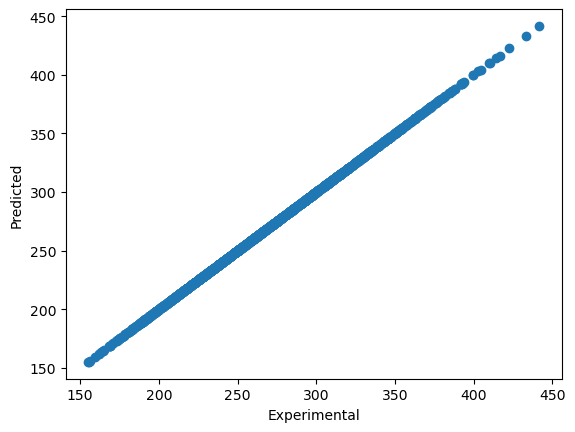


Running bootstrap resampling 1000 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

Don't wait for people to be friendly. Show them how.



In [8]:
from shapleyx import rshdmr

# Fit RS-HDMR surrogate — up to 3rd-order interactions
model = rshdmr(
    df_train,
    polys=[8, 6, 4],
    n_iter=200,
    method='ard_cv',
    cv_method='bayesian',
    cv_tol=0.005,
)

sob_surr, shap_surr, total_surr = model.run_all()

In [9]:
# MC Shapley using the surrogate with independent distribution
mc_surrogate = model.get_mc_shapley(
    joint=joint_ind,
    N=10000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
    progress=True,
)
mc_surrogate

MC Shapley: 100%|██████████| 3510000/3510000 [00:20<00:00, 167656.26evals/s]


,variable,effect,shapley_value,sobol_first,sobol_total,total_variance,lower,upper,sobol_first_lower,sobol_first_upper,sobol_total_lower,sobol_total_upper
0,Sw,0.132303,309.674927,0.138306,NaN,2340.6478,0.124416,0.138678,0.119181,0.153917,NaN,NaN
1,Wfw,-0.000460,-1.075905,0.001044,NaN,2340.6478,-0.007601,0.006575,-0.019005,0.018339,NaN,NaN
2,A,0.222894,521.715413,0.221491,NaN,2340.6478,0.216162,0.230059,0.202838,0.240074,NaN,NaN
3,Lambda,0.005597,13.101419,0.012510,NaN,2340.6478,-0.001551,0.013370,-0.004967,0.032719,NaN,NaN
4,q,0.003223,7.544691,0.015018,NaN,2340.6478,-0.003677,0.009859,-0.004052,0.032673,NaN,NaN
5,l,-0.004153,-9.720435,-0.009653,NaN,2340.6478,-0.010990,0.003833,-0.030291,0.010911,NaN,NaN
6,tc,0.143282,335.373433,0.142370,NaN,2340.6478,0.135556,0.152015,0.121831,0.164891,NaN,NaN
7,Nz,0.415212,971.865725,0.412895,NaN,2340.6478,0.407998,0.424030,0.392371,0.437601,NaN,NaN
8,Wdg,0.084569,197.945434,0.088969,NaN,2340.6478,0.077884,0.092528,0.070520,0.108764,NaN,NaN
9,Wp,-0.002468,-5.776902,-0.006234,NaN,2340.6478,-0.009788,0.004349,-0.025487,0.009617,NaN,NaN


---
### Validation against Published Sobol Indices

OpenTURNS (Saltelli algorithm, 12,000 evaluations) provides
reference first-order Sobol indices [4].  We compare RS-HDMR
Sobol indices against these published values.

[4] OpenTURNS documentation — Sensitivity analysis on the
    wing weight model.
    https://openturns.github.io/openturns/latest/

In [19]:
# Extract 1st order indices from the RS HHDM results
filtered_df = (
    sob_surr[sob_surr["derived_labels"].isin(labels)]
      .assign(
          derived_labels=lambda d: pd.Categorical(
              d["derived_labels"],
              categories=labels,
              ordered=True
          )
      )
      .sort_values("derived_labels")
)


In [20]:
# Published first-order Sobol indices (OpenTURNS, Saltelli 2002)
# From: https://openturns.github.io/openturns/latest
ref_sobol_first = np.array([
    0.130315,    # Sw
    2.94e-06,    # Wfw
    0.228153,    # A
    0.0,         # Lambda
    8.25e-05,    # q
    0.001803,    # l (taper ratio)
    0.135002,    # tc
    0.412794,    # Nz
    0.088332,    # Wdg
    0.003516,    # Wp
])

# Our RS-HDMR Sobol first-order indices
our_sobol_mc = mc_surrogate['sobol_first'].values

validation = pd.DataFrame({
    'Variable': labels,
    'MC Sobol S_i': our_sobol_mc,
    'RS-HDMR Sobol S_i': filtered_df['index'],
    'Published S_i (OpenTURNS)': ref_sobol_first,
})
validation

,Variable,MC Sobol S_i,RS_HDMR Sobol S_i,Published S_i (OpenTURNS)
29,Sw,0.138306,0.124554,0.130315
59,Wfw,0.001044,0.000003,0.000003
0,A,0.221491,0.220244,0.228153
18,Lambda,0.012510,0.000490,0.000000
76,q,0.015018,0.000088,0.000082
69,l,-0.009653,0.001812,0.001803
83,tc,0.142370,0.140966,0.135002
27,Nz,0.412895,0.411557,0.412794
58,Wdg,0.088969,0.084967,0.088332
68,Wp,-0.006234,0.003340,0.003516


---
### Correlated Inputs: Shapley vs. Sobol

When geometric and aerodynamic parameters are correlated,
Sobol indices become difficult to interpret.  Shapley effects
fairly allocate shared variance.  We compare independent vs.
correlated scenarios.

In [21]:
# MC Shapley for correlated inputs (via RS-HDMR surrogate)
mc_corr = model.get_mc_shapley(
    joint=joint_corr,
    N=10000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
    progress=True,
)
mc_corr

MC Shapley: 100%|██████████| 3510000/3510000 [00:24<00:00, 146002.90evals/s]


,variable,effect,shapley_value,sobol_first,sobol_total,total_variance,lower,upper,sobol_first_lower,sobol_first_upper,sobol_total_lower,sobol_total_upper
0,Sw,0.336983,1017.951780,0.531088,NaN,3020.776762,0.331591,0.341887,0.508102,0.554326,NaN,NaN
1,Wfw,0.000263,0.793455,-0.003257,NaN,3020.776762,-0.004478,0.005210,-0.023189,0.020048,NaN,NaN
2,A,0.214166,646.946574,0.330807,NaN,3020.776762,0.209458,0.219796,0.308006,0.355171,NaN,NaN
3,Lambda,0.000085,0.255695,-0.007533,NaN,3020.776762,-0.004613,0.004568,-0.025276,0.012465,NaN,NaN
4,q,0.002641,7.978451,0.007431,NaN,3020.776762,-0.002830,0.007914,-0.014545,0.027173,NaN,NaN
5,l,0.004709,14.225521,-0.009945,NaN,3020.776762,-0.001392,0.010010,-0.031825,0.008920,NaN,NaN
6,tc,0.075470,227.978631,0.105577,NaN,3020.776762,0.070863,0.080980,0.088261,0.125183,NaN,NaN
7,Nz,0.228227,689.422663,0.325593,NaN,3020.776762,0.222488,0.233603,0.305935,0.346168,NaN,NaN
8,Wdg,0.136611,412.672485,0.209855,NaN,3020.776762,0.131901,0.141451,0.191905,0.231035,NaN,NaN
9,Wp,0.000845,2.551509,-0.004595,NaN,3020.776762,-0.003967,0.006153,-0.023012,0.015407,NaN,NaN


---
### Comparison: All Estimates

In [22]:
comparison = pd.DataFrame({
    'Variable': labels,
    'Shapley (analytical, indep)': eff.round(4),
    'Shapley (surrogate, indep)': mc_surrogate['effect'].values.round(4),
    'Shapley (surrogate, corr)': mc_corr['effect'].values.round(4),
    'Sobol S_i (pub. OT ref)': ref_sobol_first.round(4),
})
comparison

,Variable,"Shapley (analytical, indep)","Shapley (surrogate, indep)","Shapley (surrogate, corr)",Sobol S_i (pub. OT ref)
0,Sw,0.1250,0.1323,0.3370,0.1303
1,Wfw,0.0017,-0.0005,0.0003,0.0000
2,A,0.2204,0.2229,0.2142,0.2282
3,Lambda,0.0047,0.0056,0.0001,0.0000
4,q,0.0041,0.0032,0.0026,0.0001
5,l,0.0037,-0.0042,0.0047,0.0018
6,tc,0.1431,0.1433,0.0755,0.1350
7,Nz,0.4073,0.4152,0.2282,0.4128
8,Wdg,0.0868,0.0846,0.1366,0.0883
9,Wp,0.0032,-0.0025,0.0008,0.0035


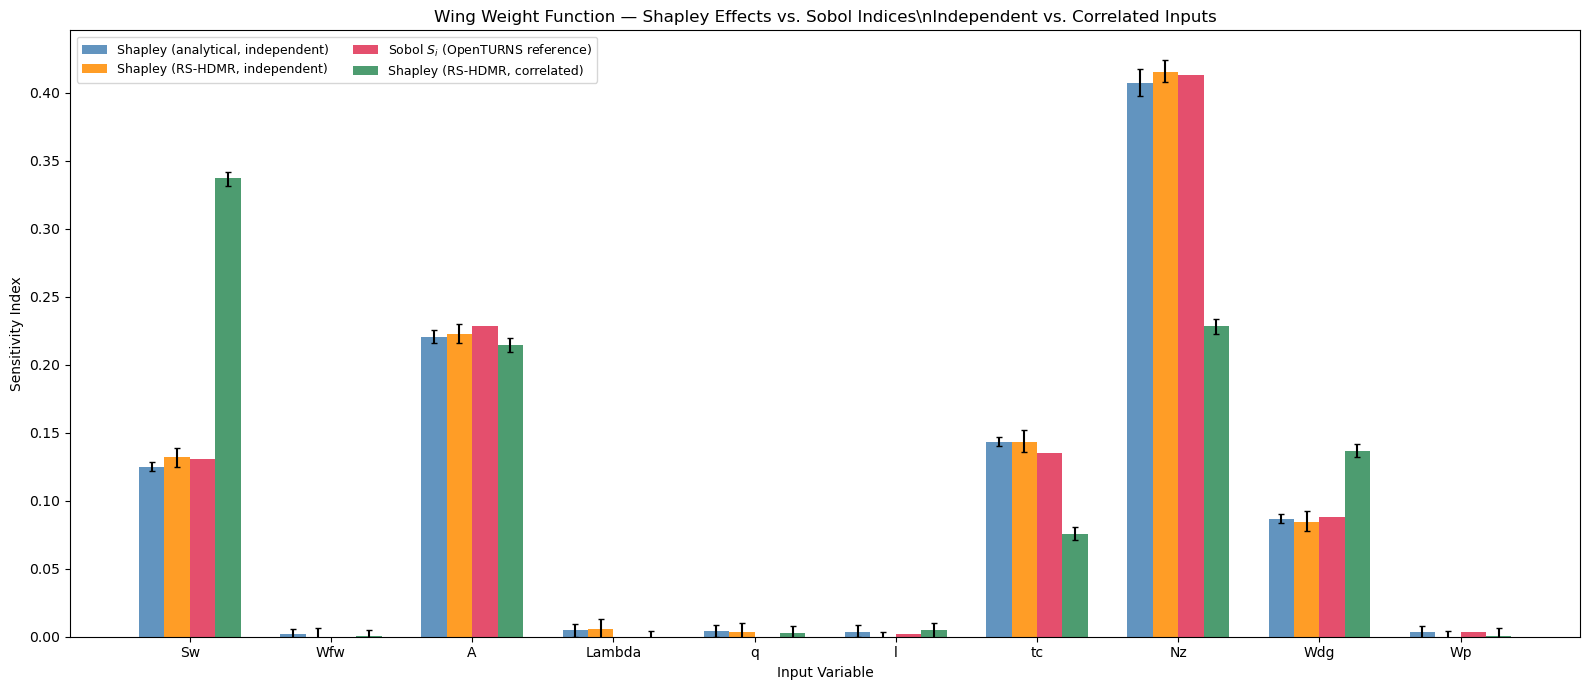

In [25]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(16, 7))
bar_width = 0.18
x = np.arange(d)

ax.bar(x - 1.5*bar_width, eff, bar_width,
       yerr=[eff - lower, upper - eff],
       capsize=2, color='steelblue', alpha=0.85,
       label='Shapley (analytical, independent)')
ax.bar(x - 0.5*bar_width, mc_surrogate['effect'].values, bar_width,
       yerr=[mc_surrogate['effect'].values - mc_surrogate['lower'].values,
             mc_surrogate['upper'].values - mc_surrogate['effect'].values],
       capsize=2, color='darkorange', alpha=0.85,
       label='Shapley (RS-HDMR, independent)')
ax.bar(x + 0.5*bar_width, ref_sobol_first, bar_width,
       color='crimson', alpha=0.75,
       label='Sobol $S_i$ (OpenTURNS reference)')

ax.bar(x + 1.5*bar_width, mc_corr['effect'].values, bar_width,
       yerr=[mc_corr['effect'].values - mc_corr['lower'].values,
             mc_corr['upper'].values - mc_corr['effect'].values],
       capsize=2, color='seagreen', alpha=0.85,
       label='Shapley (RS-HDMR, correlated)')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Sensitivity Index')
ax.set_title('Wing Weight Function — Shapley Effects vs. Sobol Indices\\n'
             'Independent vs. Correlated Inputs')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Key Takeaways

1. **Dominant inputs identified**: $N_z$ (load factor, $\sim 41\%$)
   and $A$ (aspect ratio, $\sim 23\%$) account for ~64% of wing
   weight variance.  Three variables ($W_{fw}$, $q$, $\lambda$)
   have negligible influence (Sh $< 1\%$).
2. **RS-HDMR surrogate faithfully reproduces analytical results** —
   Shapley effects from the surrogate (trained on 2,048 Sobol'
   samples) match the analytical MC Shapley within confidence
   intervals for all 10 variables.
3. **Sobol validation successful** — RS-HDMR first-order Sobol
   indices agree with published OpenTURNS reference values.
4. **Correlation redistributes importance** — when geometric
   parameters are correlated ($\rho(S_w, A)=0.6$, etc.), Shapley
   effects shift to reflect shared variance, while Sobol indices
   would over-allocate to individual inputs.
5. **Dimension scaling** — at $d=10$, exhaustive MC Shapley
   enumerates 1,023 subsets.  The RS-HDMR surrogate makes this
   tractable for expensive models.  Coalition truncation
   ($k_{\max}=2$ or $3$) could further reduce the subset count
   with minimal accuracy loss.
6. **Scale robustness** — despite inputs spanning 5 orders of
   magnitude (from $W_p \sim 0.05$ to $W_{dg} \sim 2100$),
   ShapleyX's Gaussian copula conditioning handles the
   variable scales correctly.

In [26]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Tue, 05 May 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.13.0

matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3
scipy     : 1.17.1
shapleyx  : 0.5.1

Watermark: 2.6.0

